# TSLA stock price prediction

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV
from sklearn.metrics import mean_squared_error,mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from scipy.stats import randint, uniform
import warnings
warnings.filterwarnings('ignore')

In [4]:
data=pd.read_csv('TSLA.csv')

In [5]:
df=data.copy()
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2010-06-29,3.800,5.000,3.508,4.778,4.778,93831500
1,2010-06-30,5.158,6.084,4.660,4.766,4.766,85935500
2,2010-07-01,5.000,5.184,4.054,4.392,4.392,41094000
3,2010-07-02,4.600,4.620,3.742,3.840,3.840,25699000
4,2010-07-06,4.000,4.000,3.166,3.222,3.222,34334500


In [6]:
df.tail()

,Date,Open,High,Low,Close,Adj Close,Volume
2951,2022-03-18,874.489990,907.849976,867.390015,905.390015,905.390015,33408500
2952,2022-03-21,914.979980,942.849976,907.090027,921.159973,921.159973,27327200
2953,2022-03-22,930.000000,997.859985,921.750000,993.979980,993.979980,35289500
2954,2022-03-23,979.940002,1040.699951,976.400024,999.109985,999.109985,40225400
2955,2022-03-24,1009.729980,1024.489990,988.799988,1013.919983,1013.919983,22901900


In [7]:
df.shape

(2956, 7)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2956 entries, 0 to 2955
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       2956 non-null   object 
 1   Open       2956 non-null   float64
 2   High       2956 non-null   float64
 3   Low        2956 non-null   float64
 4   Close      2956 non-null   float64
 5   Adj Close  2956 non-null   float64
 6   Volume     2956 non-null   int64  
dtypes: float64(5), int64(1), object(1)
memory usage: 161.8+ KB


In [9]:
# Checking Null Values
df.isnull().sum()

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Open,2956.0,1.386913e+02,2.500448e+02,3.228,1.962700e+01,4.665700e+01,6.805700e+01,1.234410e+03
High,2956.0,1.417716e+02,2.558632e+02,3.326,2.040200e+01,4.748700e+01,6.935750e+01,1.243490e+03
Low,2956.0,1.354260e+02,2.437742e+02,2.996,1.912750e+01,4.582000e+01,6.691150e+01,1.217000e+03
Close,2956.0,1.387622e+02,2.501231e+02,3.160,1.961500e+01,4.654500e+01,6.810400e+01,1.229910e+03
Adj Close,2956.0,1.387622e+02,2.501231e+02,3.160,1.961500e+01,4.654500e+01,6.810400e+01,1.229910e+03
Volume,2956.0,3.131449e+07,2.798383e+07,592500.000,1.310288e+07,2.488680e+07,3.973875e+07,3.046940e+08


In [11]:
# Data visulozation

<Figure size 5000x5000 with 0 Axes>

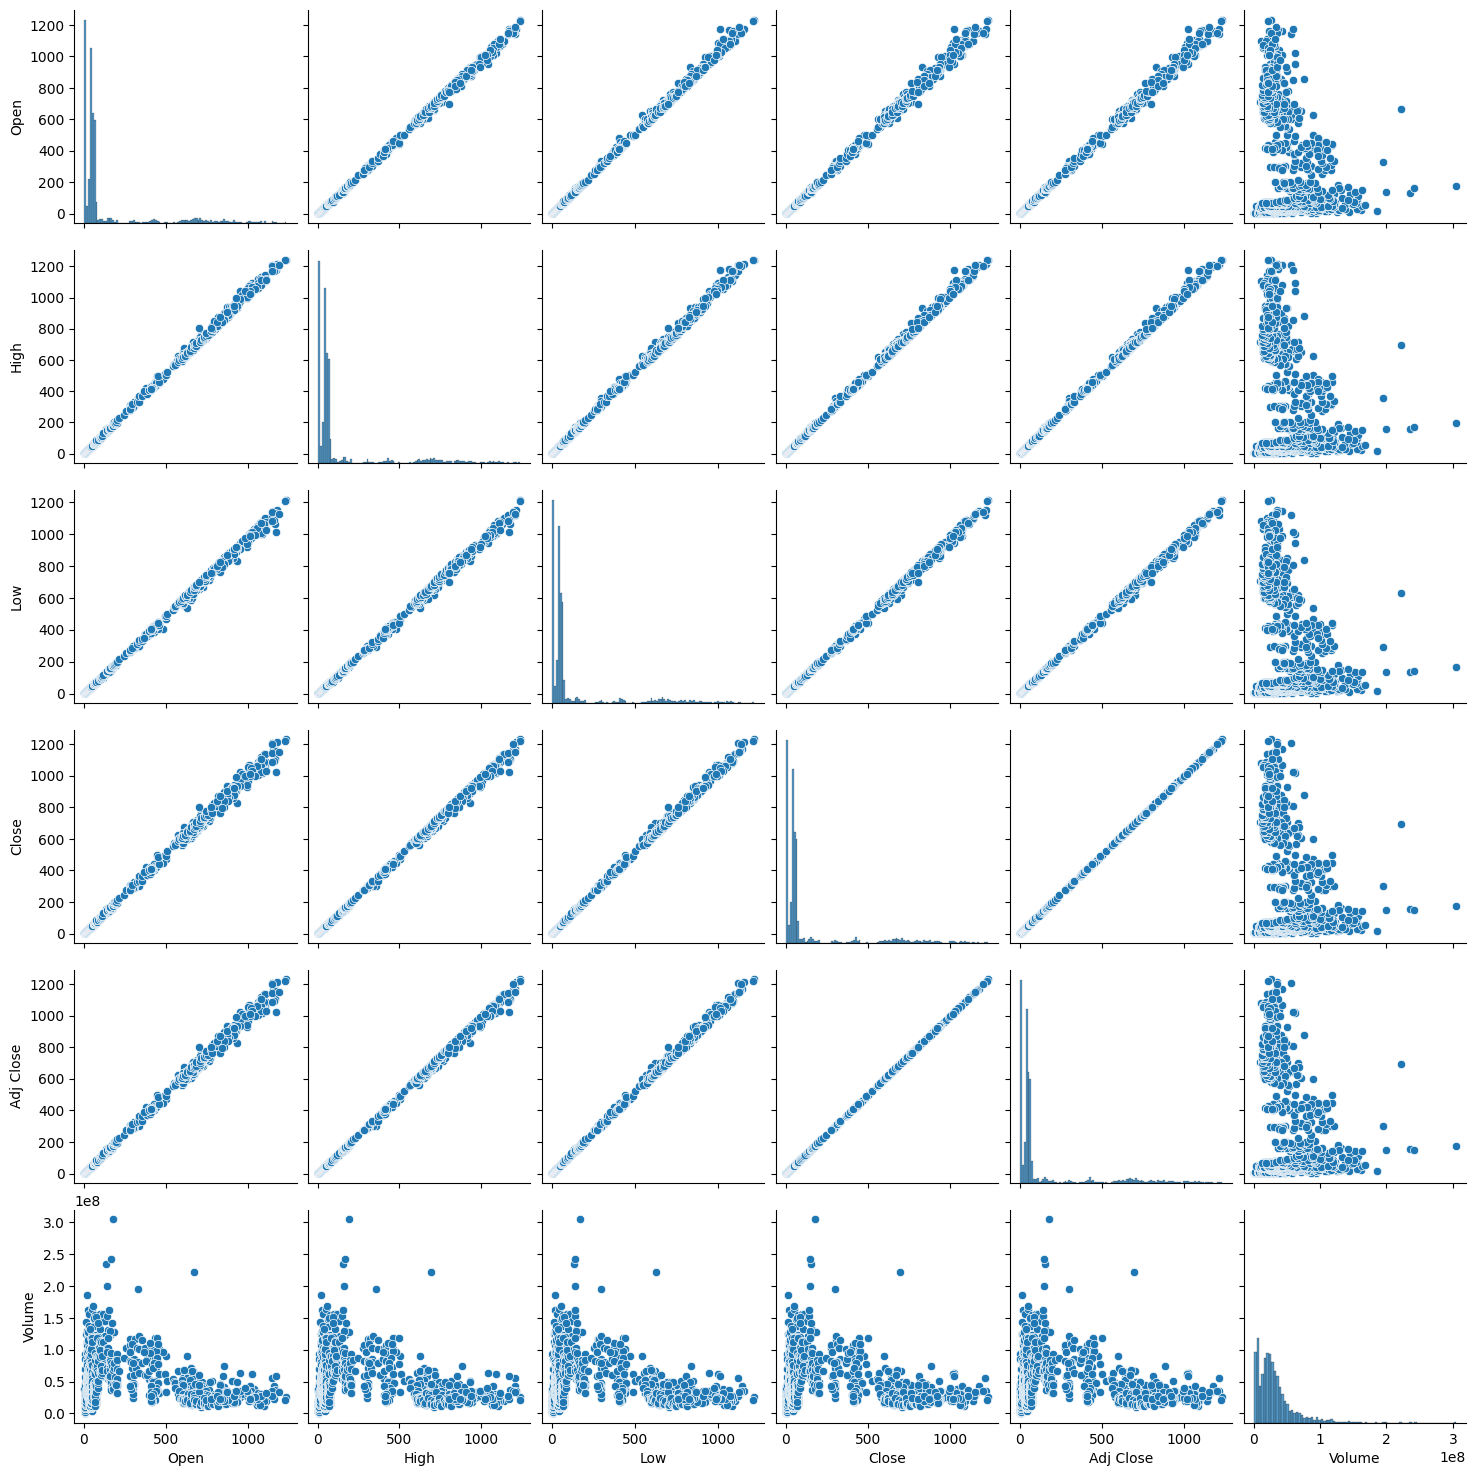

In [12]:
plt.figure(figsize=(50,50))
sns.pairplot(df,palette="hls")

<Axes: xlabel='Open', ylabel='Close'>

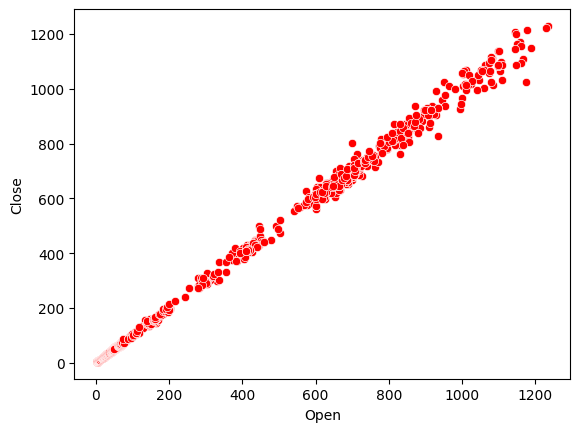

In [13]:
sns.scatterplot(x=df['Open'],y=df['Close'],color='red')

<Axes: xlabel='Open', ylabel='Count'>

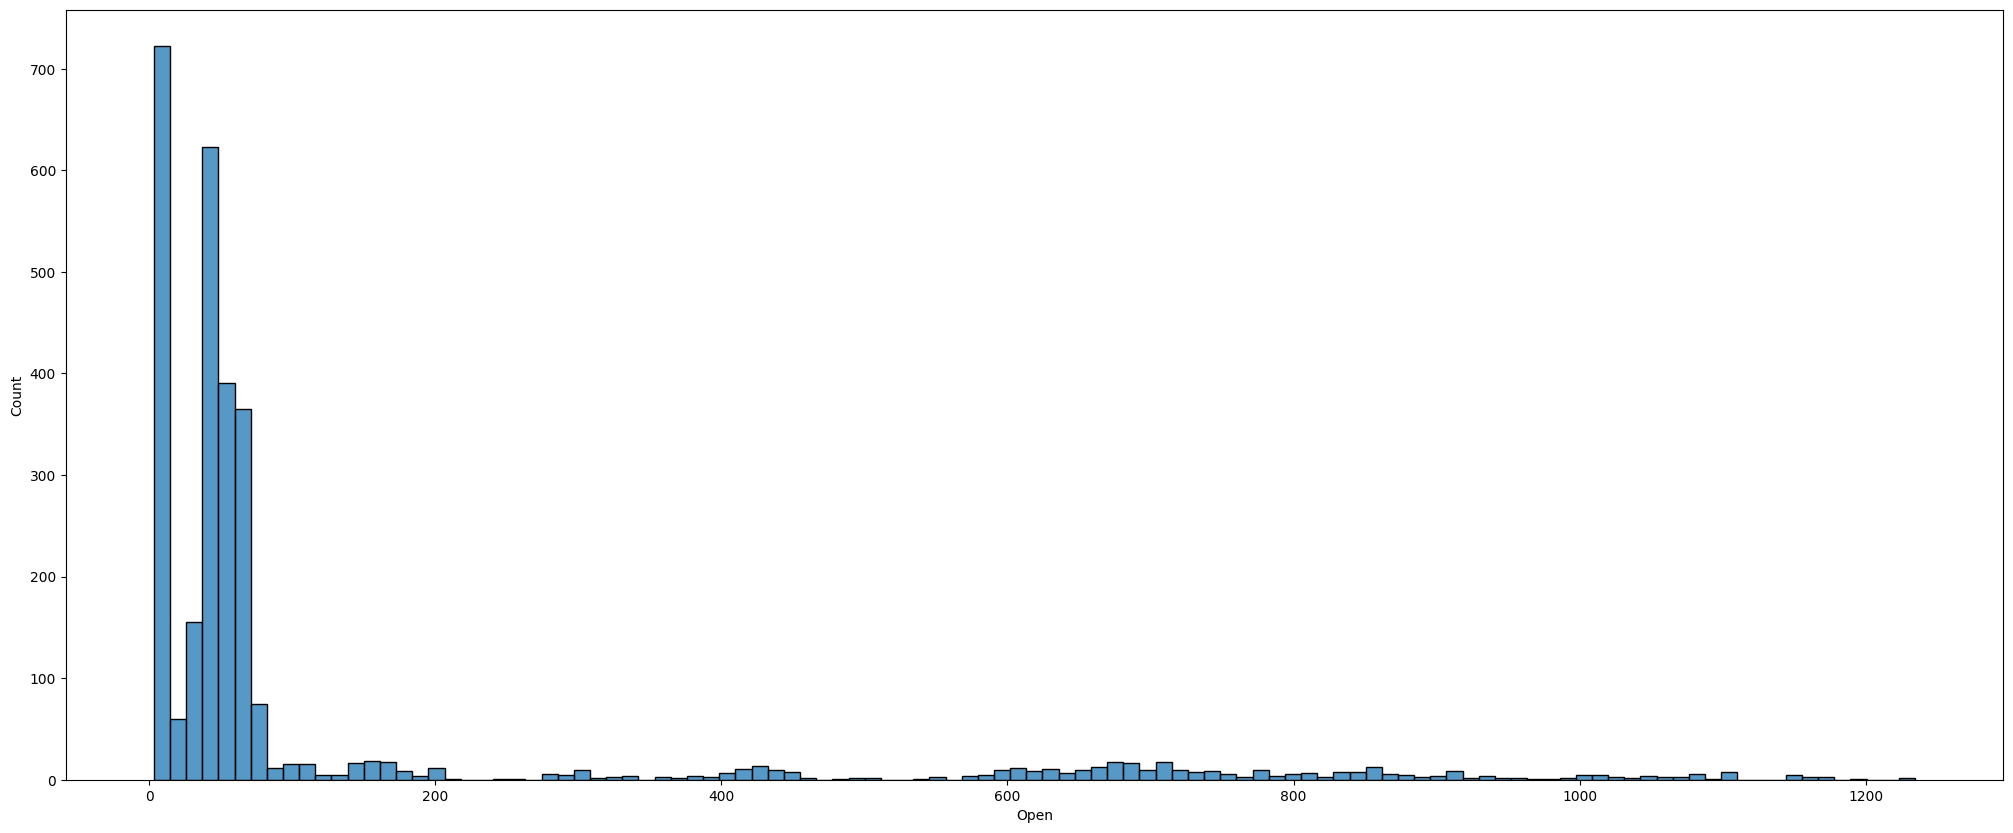

In [14]:
plt.figure(figsize=(25,10))
sns.histplot(df,x=df['Open'])

<Axes: xlabel='Close', ylabel='Count'>

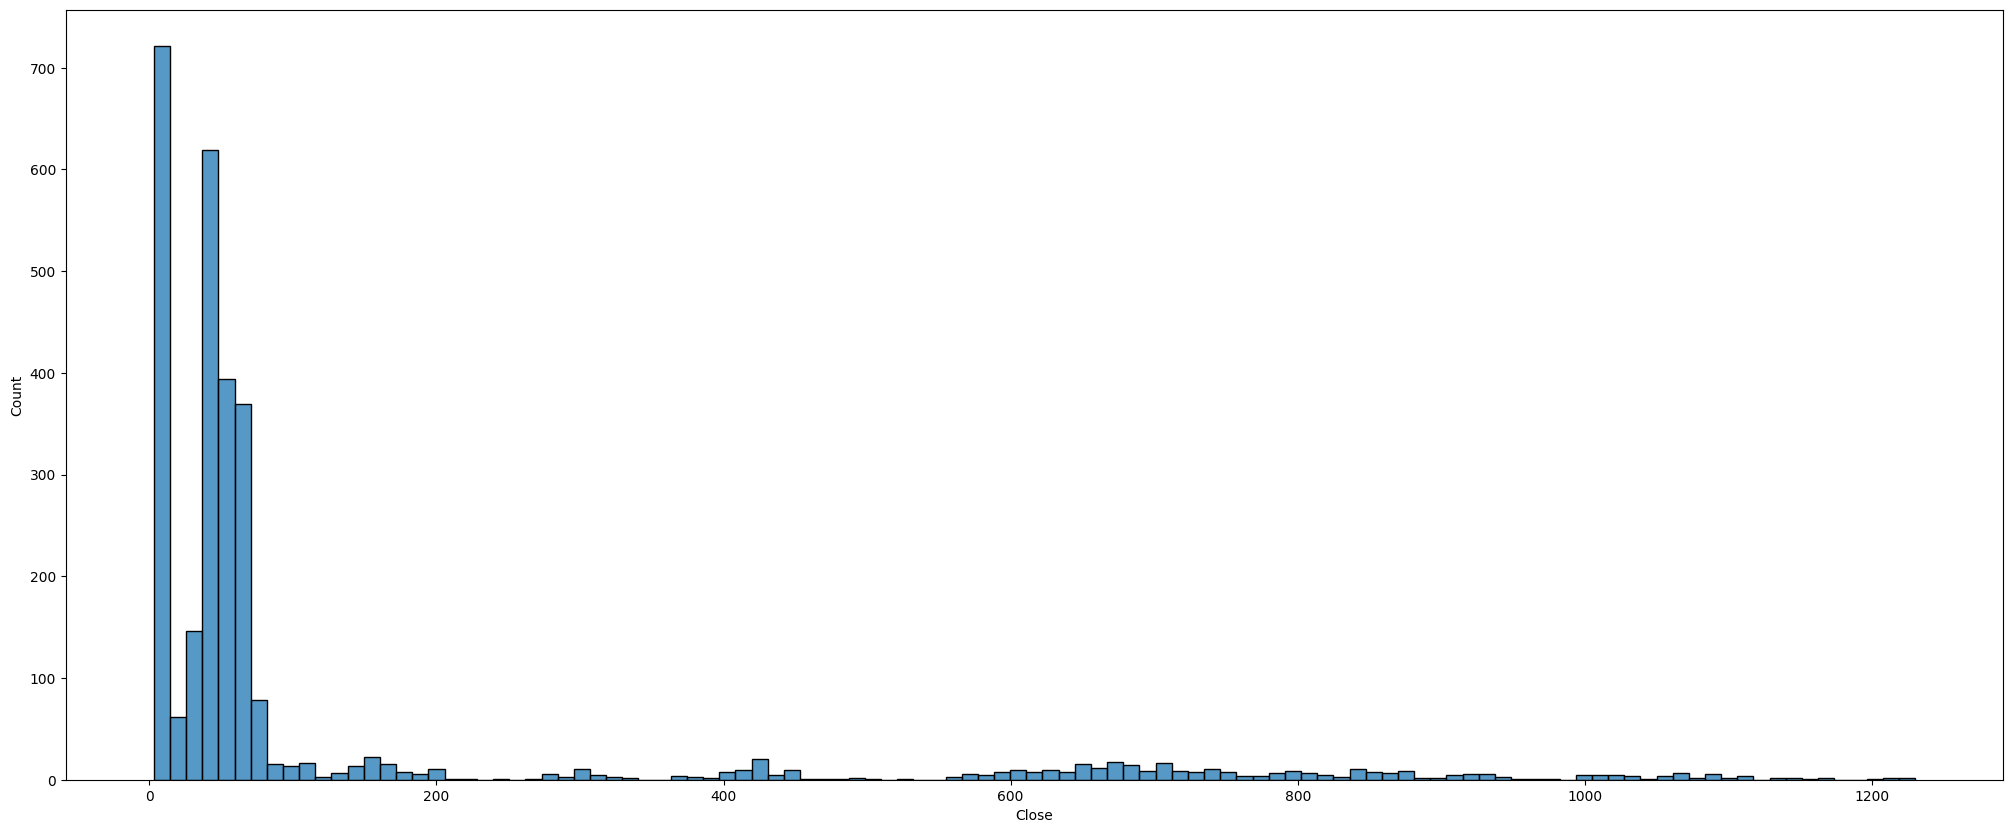

In [15]:
plt.figure(figsize=(25,10))
sns.histplot(df,x=df['Close'])

<Axes: xlabel='High', ylabel='Open'>

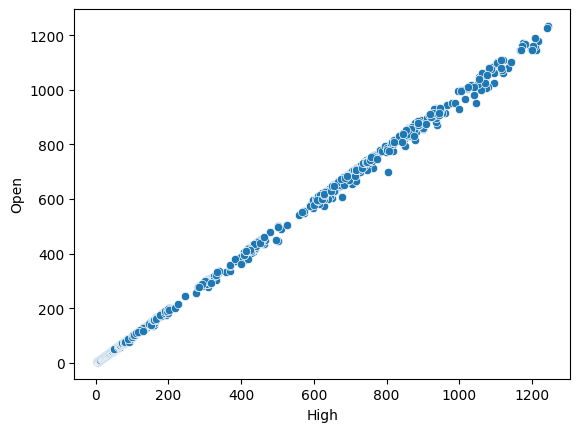

In [16]:
sns.scatterplot(df,x=df['High'],y=df['Open'])

<Axes: xlabel='High', ylabel='Close'>

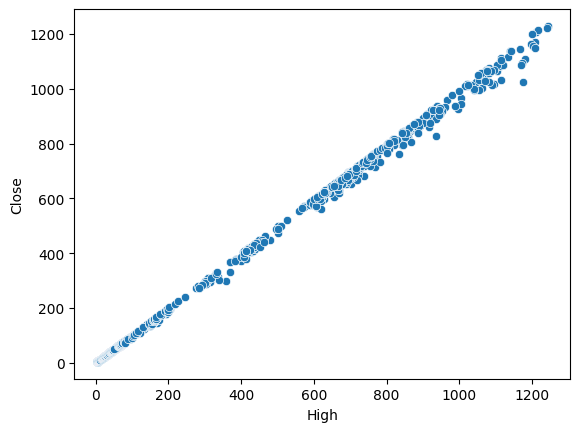

In [17]:
sns.scatterplot(df,x=df['High'],y=df['Close'])

<Axes: xlabel='Low', ylabel='Open'>

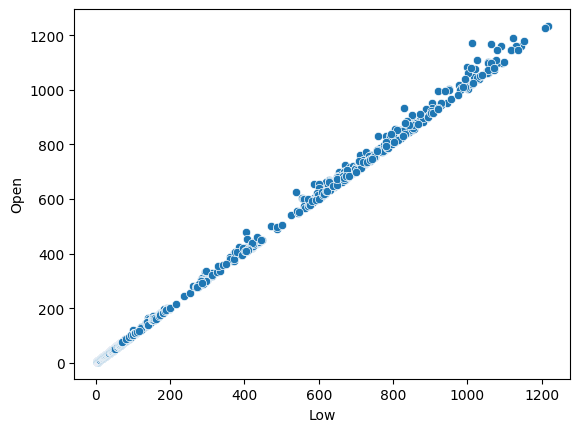

In [18]:
sns.scatterplot(df,x=df['Low'],y=df['Open'])

<Axes: xlabel='Low', ylabel='Close'>

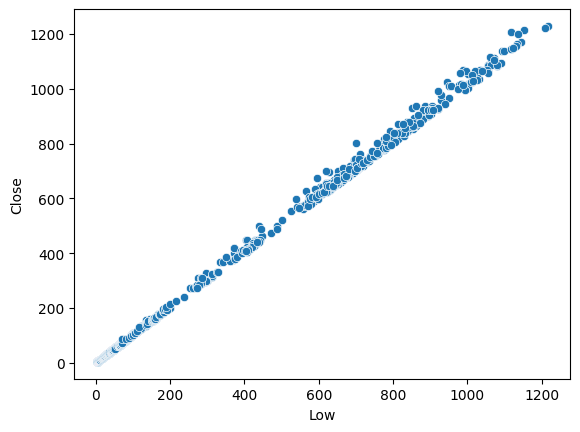

In [19]:
sns.scatterplot(df,x=df['Low'],y=df['Close'])

In [20]:
# We delete the Date and adj close column because Date is categorical column and Adj  close column is same as Close column

In [21]:
df1=df.drop(columns=['Date','Adj Close'])

In [22]:
# correlation
corr=df1.corr()
corr

,Open,High,Low,Close,Volume
Open,1.000000,0.999726,0.999617,0.999247,0.089750
High,0.999726,1.000000,0.999595,0.999666,0.093625
Low,0.999617,0.999595,1.000000,0.999670,0.085906
Close,0.999247,0.999666,0.999670,1.000000,0.090602
Volume,0.089750,0.093625,0.085906,0.090602,1.000000


<Axes: >

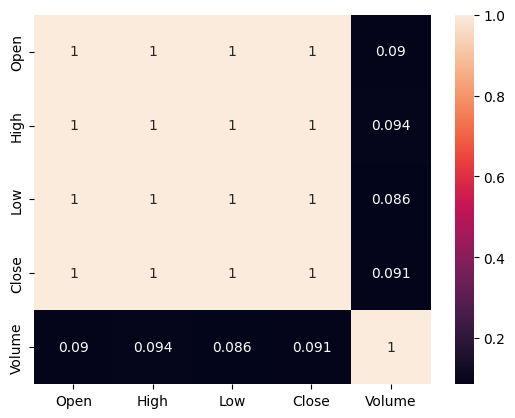

In [23]:
sns.heatmap(corr,annot=True)

In [24]:
x=df1[['Open','High','Low','Volume']]
y=df1['Close']

In [25]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [26]:
X_train.head()

,Open,High,Low,Volume
1872,61.299999,61.653999,60.122002,29175500
1091,45.919998,48.919998,45.650002,52581500
2397,92.279999,94.325996,90.671997,89410500
2940,878.770020,886.440002,832.599976,20541200
1564,39.150002,39.584000,38.972000,11272500


In [27]:
y_train.head()

1872     61.040001
1091     48.554001
2397     93.811996
2940    839.289978
1564     39.282001
Name: Close, dtype: float64

In [28]:
# scaling the dataset
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
X_train_trf=scaler.fit_transform(X_train)
X_test_trf=scaler.fit_transform(X_test)

In [29]:
X_train_trf

array([[0.04716768, 0.04703249, 0.04705586, 0.09399164],
       [0.03467562, 0.03676449, 0.03513498, 0.17095937],
       [0.07233049, 0.07337739, 0.07222052, 0.29206696],
       ...,
       [0.03373506, 0.03349396, 0.03369676, 0.07213381],
       [0.03966757, 0.03935286, 0.03954518, 0.0573131 ],
       [0.01677087, 0.01710903, 0.01665892, 0.22635535]], shape=(2364, 4))

In [30]:
X_test_trf

array([[0.04945065, 0.04883109, 0.04938523, 0.34443317],
       [0.03691439, 0.03595381, 0.03676407, 0.2363172 ],
       [0.0381968 , 0.03799165, 0.03821933, 0.22317503],
       ...,
       [0.73410369, 0.72161521, 0.73972503, 0.09196486],
       [0.00216702, 0.00204454, 0.00214218, 0.03604895],
       [0.04648626, 0.04583801, 0.04671193, 0.21111666]], shape=(592, 4))

In [35]:
# Define preprocessing pipeline
preprocessor = Pipeline([
    ('scaler', StandardScaler())
])

# Define models and their parameter grids
models = {
    'Random Forest': {
        'model': RandomForestRegressor(random_state=42),
        'params': {
            'model__n_estimators': [50, 100, 200],
            'model__max_depth': [None, 10, 20],
            'model__min_samples_split': [2, 5, 10]
        }
    },
    'Gradient Boosting': {
        'model': GradientBoostingRegressor(random_state=42),
        'params': {
            'model__n_estimators': [50, 100, 200],
            'model__learning_rate': [0.01, 0.1, 0.2],
            'model__max_depth': [3, 5, 7]
        }
    },
    'XGBoost': {
        'model': XGBRegressor(random_state=42),
        'params': {
            'model__n_estimators': [50, 100, 200],
            'model__learning_rate': [0.01, 0.1, 0.2],
            'model__max_depth': [3, 5, 7]
        }
    },
    'SVR': {
        'model': SVR(),
        'params': {
            'model__C': [0.1, 1, 10],
            'model__kernel': ['linear', 'rbf'],
            'model__gamma': ['scale', 'auto']
        }
    },
    'Ridge': {
        'model': Ridge(random_state=42),
        'params': {
            'model__alpha': [0.1, 1, 10]
        }
    },
    'Lasso': {
        'model': Lasso(random_state=42),
        'params': {
            'model__alpha': [0.1, 1, 10]
        }
    },
    'ElasticNet': {
        'model': ElasticNet(random_state=42),
        'params': {
            'model__alpha': [0.1, 1, 10],
            'model__l1_ratio': [0.2, 0.5, 0.8]
        }
    },
    'KNN': {
        'model': KNeighborsRegressor(),
        'params': {
            'model__n_neighbors': [3, 5, 7],
            'model__weights': ['uniform', 'distance']
        }
    },
    'Decision Tree': {
        'model': DecisionTreeRegressor(random_state=42),
        'params': {
            'model__max_depth': [None, 5, 10, 20],
            'model__min_samples_split': [2, 5, 10]
        }
    }
}

# Perform GridSearchCV for each model
best_models = {}
for model_name, model_info in models.items():
    # Create pipeline with preprocessor and model
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model_info['model'])
    ])
    
    # Setup GridSearchCV
    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=model_info['params'],
        cv=5,
        scoring='r2',
        n_jobs=-1,
        verbose=1
    )
    
    print(f"\nTraining {model_name}...")
    grid_search.fit(X_train, y_train)
    
    # Store best model and its score
    best_models[model_name] = {
        'model': grid_search.best_estimator_,
        'best_score': grid_search.best_score_,
        'best_params': grid_search.best_params_
    }
    
    # Print results
    print(f"Best parameters for {model_name}: {grid_search.best_params_}")
    print(f"Best cross-validation score (R2 Score): {grid_search.best_score_:.4f}")

# Find the best model among all
best_model_name = max(best_models.keys(), key=lambda x: best_models[x]['best_score'])
best_model = best_models[best_model_name]['model']

print("\n" + "="*50)
print(f"Best overall model: {best_model_name}")
print(f"Best parameters: {best_models[best_model_name]['best_params']}")
print(f"Best cross-validation score (R2 Score): {best_models[best_model_name]['best_score']:.4f}")

# Evaluate on test set
y_pred = best_model.predict(X_test)

print("\nTest set performance:")
MSE=mean_squared_error(y_test,y_pred)
RMSE=np.sqrt(MSE)
MAE = mean_absolute_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)
k=X_test.shape[1]
n=len(X_test)
adj_r2 = 1-(1-r2)*(n-1)/(n-k-1)
print("MSE:",MSE, "\nRMSE:",RMSE,"\nMAE:",MAE,"\nr2:",r2,"\nAdjusted r2:",adj_r2)


Training Random Forest...
Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best parameters for Random Forest: {'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 50}
Best cross-validation score (R2 Score): 0.9994

Training Gradient Boosting...
Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best parameters for Gradient Boosting: {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 200}
Best cross-validation score (R2 Score): 0.9994

Training XGBoost...
Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best parameters for XGBoost: {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 50}
Best cross-validation score (R2 Score): 0.9989

Training SVR...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best parameters for SVR: {'model__C': 10, 'model__gamma': 'scale', 'model__kernel': 'linear'}
Best cross-validation score (R2 Score): 0.9994

Training Ridge...
Fitting

<Axes: xlabel='Close'>

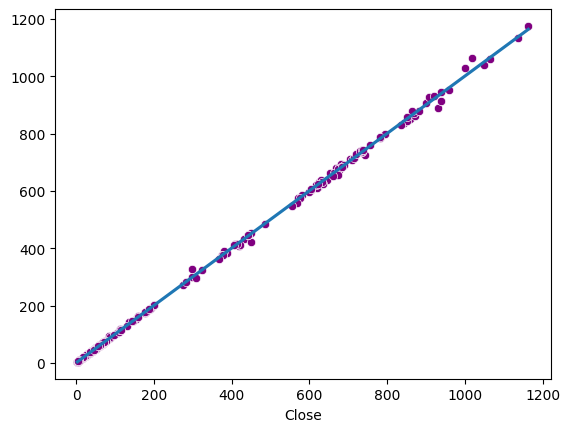

In [36]:
sns.scatterplot(x=y_test,y=y_pred,color='Purple')
sns.regplot(x=y_test,y=y_pred,scatter=False)

In [37]:
# Define preprocessing pipeline
preprocessor = Pipeline([
    ('scaler', StandardScaler())
])

# Define models and their parameter distributions for random search
models = {
    'Random Forest': {
        'model': RandomForestRegressor(random_state=42),
        'params': {
            'model__n_estimators': randint(50, 300),
            'model__max_depth': [None] + list(randint(5, 50).rvs(5)),
            'model__min_samples_split': randint(2, 11),
            'model__min_samples_leaf': randint(1, 5),
            'model__max_features': ['sqrt', 'log2', None]
        }
    },
    'Gradient Boosting': {
        'model': GradientBoostingRegressor(random_state=42),
        'params': {
            'model__n_estimators': randint(50, 300),
            'model__learning_rate': uniform(0.01, 0.3),
            'model__max_depth': randint(3, 10),
            'model__min_samples_split': randint(2, 11),
            'model__min_samples_leaf': randint(1, 5)
        }
    },
    'XGBoost': {
        'model': XGBRegressor(random_state=42),
        'params': {
            'model__n_estimators': randint(50, 300),
            'model__learning_rate': uniform(0.01, 0.3),
            'model__max_depth': randint(3, 10),
            'model__subsample': uniform(0.6, 0.4),  # range 0.6-1.0
            'model__colsample_bytree': uniform(0.6, 0.4)
        }
    },
    'SVR': {
        'model': SVR(),
        'params': {
            'model__C': uniform(0.1, 10),  # range 0.1-10.1
            'model__kernel': ['linear', 'rbf', 'poly'],
            'model__gamma': ['scale', 'auto'] + list(uniform(0.01, 1).rvs(5))
        }
    },
    'Ridge': {
        'model': Ridge(random_state=42),
        'params': {
            'model__alpha': uniform(0.1, 10)
        }
    },
    'Lasso': {
        'model': Lasso(random_state=42),
        'params': {
            'model__alpha': uniform(0.1, 10)
        }
    },
    'ElasticNet': {
        'model': ElasticNet(random_state=42),
        'params': {
            'model__alpha': uniform(0.1, 10),
            'model__l1_ratio': uniform(0, 1)  # range 0-1
        }
    },
    'KNN': {
        'model': KNeighborsRegressor(),
        'params': {
            'model__n_neighbors': randint(1, 20),
            'model__weights': ['uniform', 'distance'],
            'model__p': [1, 2]  # 1: manhattan, 2: euclidean
        }
    },
    'Decision Tree': {
        'model': DecisionTreeRegressor(random_state=42),
        'params': {
            'model__max_depth': [None] + list(randint(5, 50).rvs(5)),
            'model__min_samples_split': randint(2, 11),
            'model__min_samples_leaf': randint(1, 5)
        }
    }
}

# Perform RandomizedSearchCV for each model
best_models = {}
n_iter_search = 20  # Number of parameter settings sampled per model

for model_name, model_info in models.items():
    # Create pipeline with preprocessor and model
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model_info['model'])
    ])
    
    # Setup RandomizedSearchCV
    random_search = RandomizedSearchCV(
        estimator=pipeline,
        param_distributions=model_info['params'],
        n_iter=n_iter_search,
        cv=5,
        scoring='r2',
        n_jobs=-1,
        verbose=1,
        random_state=42
    )
    
    print(f"\nTraining {model_name} with randomized search...")
    random_search.fit(X_train, y_train)
    
    # Store best model and its score
    best_models[model_name] = {
        'model': random_search.best_estimator_,
        'best_score': random_search.best_score_,
        'best_params': random_search.best_params_
    }
    
    # Print results
    print(f"Best parameters for {model_name}: {random_search.best_params_}")
    print(f"Best cross-validation score (R2 Score): {random_search.best_score_:.4f}")




Training Random Forest with randomized search...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters for Random Forest: {'model__max_depth': np.int64(39), 'model__max_features': None, 'model__min_samples_leaf': 2, 'model__min_samples_split': 4, 'model__n_estimators': 264}
Best cross-validation score (R2 Score): 0.9994

Training Gradient Boosting with randomized search...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters for Gradient Boosting: {'model__learning_rate': np.float64(0.03930163420191516), 'model__max_depth': 6, 'model__min_samples_leaf': 4, 'model__min_samples_split': 8, 'model__n_estimators': 221}
Best cross-validation score (R2 Score): 0.9994

Training XGBoost with randomized search...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters for XGBoost: {'model__colsample_bytree': np.float64(0.6296178606936361), 'model__learning_rate': np.float64(0.11753971856328177), 'model__max_depth': 3, 'model

In [38]:
# Find the best model among all
best_model_name = max(best_models.keys(), key=lambda x: best_models[x]['best_score'])
best_model = best_models[best_model_name]['model']

print("\n" + "="*50)
print(f"Best overall model: {best_model_name}")
print(f"Best parameters: {best_models[best_model_name]['best_params']}")
print(f"Best cross-validation score (R2 Score): {best_models[best_model_name]['best_score']:.4f}")


Best overall model: Ridge
Best parameters: {'model__alpha': np.float64(0.30584494295802445)}
Best cross-validation score (R2 Score): 0.9997


In [39]:
# Evaluate on test set
y_pred = best_model.predict(X_test)

print("\nTest set performance:")
MSE=mean_squared_error(y_test,y_pred)
RMSE=np.sqrt(MSE)
MAE = mean_absolute_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)
k=X_test.shape[1]
n=len(X_test)
adj_r2 = 1-(1-r2)*(n-1)/(n-k-1)
print("MSE:",MSE, "\nRMSE:",RMSE,"\nMAE:",MAE,"\nr2:",r2,"\nAdjusted r2:",adj_r2)


Test set performance:
MSE: 19.335121960678283 
RMSE: 4.39717204128725 
MAE: 1.5616159926909845 
r2: 0.9996705917836346 
Adjusted r2: 0.9996683470939149


<Axes: xlabel='Close'>

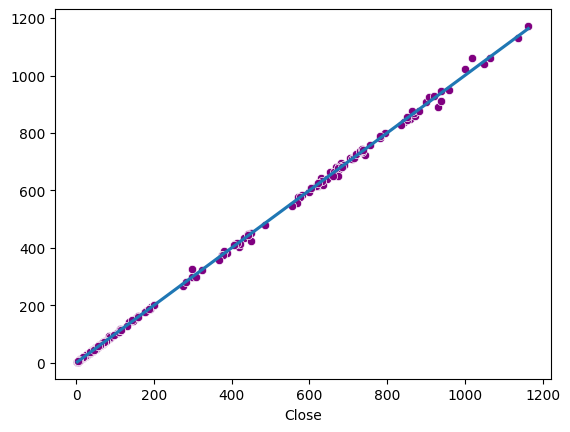

In [40]:
sns.scatterplot(x=y_test,y=y_pred,color='Purple')
sns.regplot(x=y_test,y=y_pred,scatter=False)